11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8791 - loss: 0.4120 - val_accuracy: 0.9763 - val_loss: 0.0764
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9823 - loss: 0.0587 - val_accuracy: 0.9868 - val_loss: 0.0442
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9889 - loss: 0.0350 - val_accuracy: 0.9888 - val_loss: 0.0387
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9922 - loss: 0.0254 - val_accuracy: 0.9894 - val_loss: 0.0365
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9854 - val_loss: 0.0497


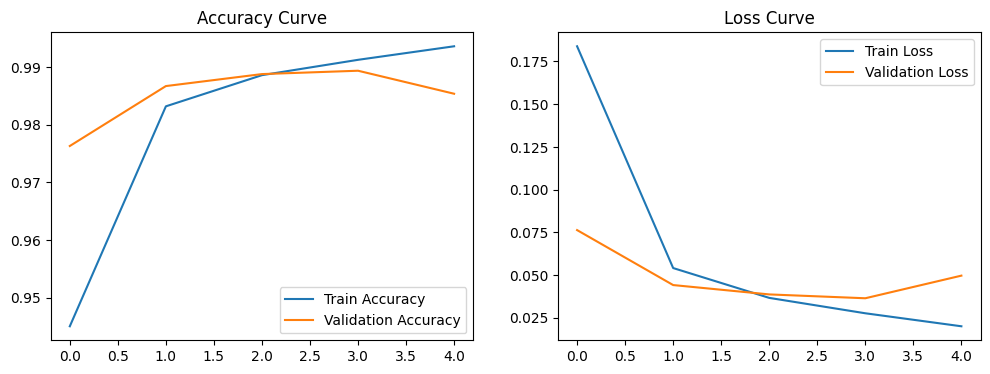

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9821 - loss: 0.0493

Test Accuracy: 0.9868000149726868
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Image 1: Predicted = 7, Actual = 7


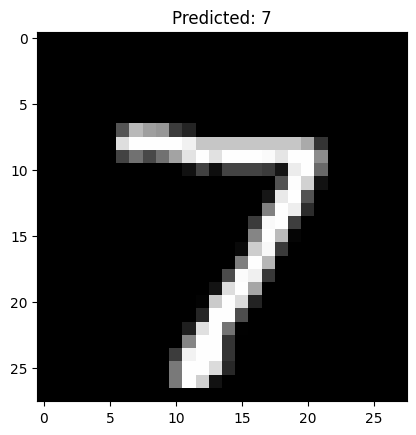

Image 2: Predicted = 2, Actual = 2


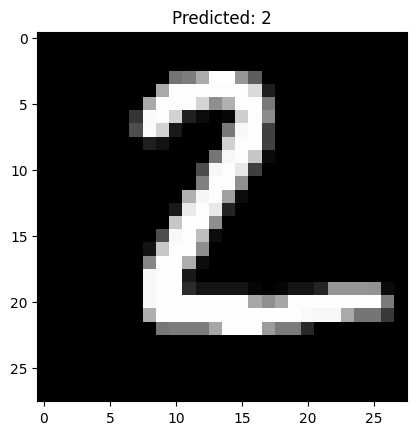

Image 3: Predicted = 1, Actual = 1


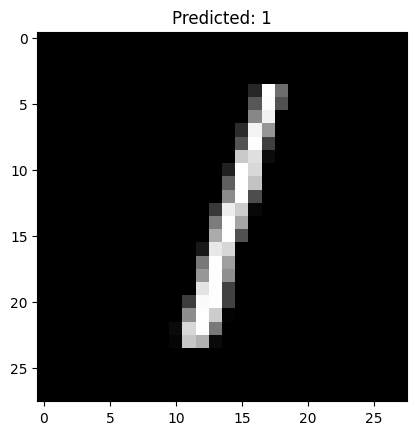

Image 4: Predicted = 0, Actual = 0


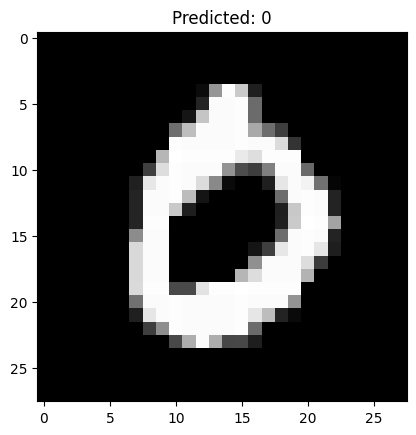

Image 5: Predicted = 4, Actual = 4


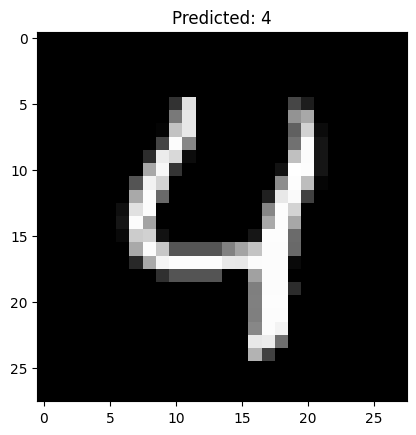

In [ ]:

# Step 1: Import Required Libraries
# -----------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
# -----------------------------------------------------------
# Step 2: Load MNIST Dataset
# -----------------------------------------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0
# Reshape for CNN (add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
# -----------------------------------------------------------
# Step 3: Build Deep CNN Model
# -----------------------------------------------------------
model = Sequential([
 Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
 MaxPooling2D((2,2)),

 Conv2D(64, (3,3), activation='relu'),
 MaxPooling2D((2,2)),

 Flatten(),
 Dense(128, activation='relu'),
 Dense(10, activation='softmax')
])
# Compile the model
model.compile(
 optimizer='adam',
 loss='categorical_crossentropy',
 metrics=['accuracy']
)
model.summary()
# -----------------------------------------------------------
# Step 4: Train the Model
# -----------------------------------------------------------
history = model.fit(
 X_train, y_train,
 epochs=5,
 batch_size=64,
 validation_split=0.2
)
# -----------------------------------------------------------
# Step 5: Plot Training Progress
# -----------------------------------------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.legend()
plt.show()
# -----------------------------------------------------------
# Step 6: Evaluate Model
# -----------------------------------------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", test_accuracy)
# -----------------------------------------------------------
# Step 7: Inference Example
# -----------------------------------------------------------
predictions = model.predict(X_test)
for i in range(5):
 predicted_digit = np.argmax(predictions[i])
 actual_digit = np.argmax(y_test[i])
 print(f"Image {i+1}: Predicted = {predicted_digit}, Actual = {actual_digit}")
 plt.imshow(X_test[i].reshape(28,28), cmap='gray')
 plt.title(f"Predicted: {predicted_digit}")
 plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7364 - loss: 0.7522 - val_accuracy: 0.8724 - val_loss: 0.3619
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8695 - loss: 0.3548 - val_accuracy: 0.8798 - val_loss: 0.3290
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8864 - loss: 0.3107 - val_accuracy: 0.8917 - val_loss: 0.2951
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9013 - loss: 0.2695 - val_accuracy: 0.8985 - val_loss: 0.2800
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9091 - loss: 0.2463 - val_accuracy: 0.9022 - val_loss: 0.2622


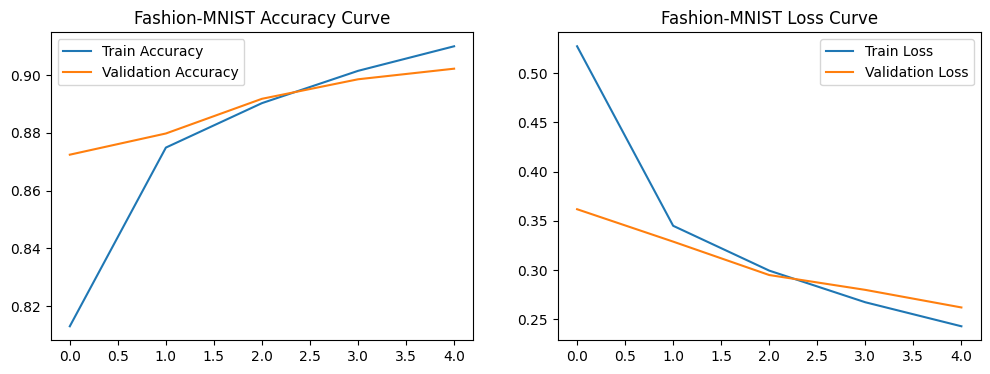

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9017 - loss: 0.2788

Fashion-MNIST Test Accuracy: 0.9023000001907349
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Image 1: Predicted = Ankle boot (9), Actual = Ankle boot (9)
Image 2: Predicted = Pullover (2), Actual = Pullover (2)
Image 3: Predicted = Trouser (1), Actual = Trouser (1)
Image 4: Predicted = Trouser (1), Actual = Trouser (1)
Image 5: Predicted = Shirt (6), Actual = Shirt (6)


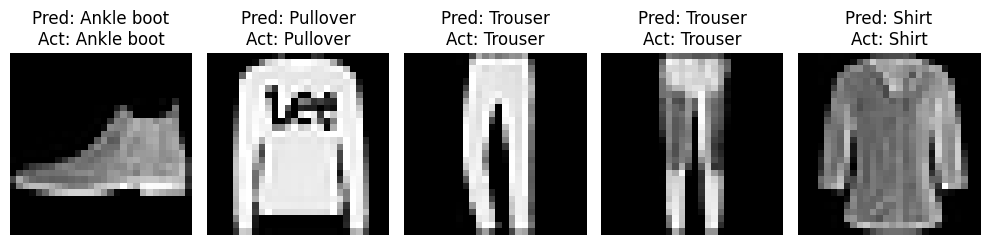

In [ ]:
# Step 1: Import Required Libraries
# -----------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist # Using Fashion-MNIST dataset
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# -----------------------------------------------------------
# Step 2: Load Fashion-MNIST Dataset
# -----------------------------------------------------------
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = fashion_mnist.load_data()

# Normalize pixel values (0–255 → 0–1)
X_train_fashion = X_train_fashion / 255.0
X_test_fashion = X_test_fashion / 255.0

# Reshape for CNN (add channel dimension)
X_train_fashion = X_train_fashion.reshape(-1, 28, 28, 1)
X_test_fashion = X_test_fashion.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train_fashion = to_categorical(y_train_fashion, 10)
y_test_fashion = to_categorical(y_test_fashion, 10)

# -----------------------------------------------------------
# Step 3: Build Deep CNN Model for Fashion-MNIST
# -----------------------------------------------------------
model_fashion = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model_fashion.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_fashion.summary()

# -----------------------------------------------------------
# Step 4: Train the Model
# -----------------------------------------------------------
history_fashion = model_fashion.fit(
    X_train_fashion, y_train_fashion,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# -----------------------------------------------------------
# Step 5: Plot Training Progress
# -----------------------------------------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_fashion.history['accuracy'], label='Train Accuracy')
plt.plot(history_fashion.history['val_accuracy'], label='Validation Accuracy')
plt.title("Fashion-MNIST Accuracy Curve")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_fashion.history['loss'], label='Train Loss')
plt.plot(history_fashion.history['val_loss'], label='Validation Loss')
plt.title("Fashion-MNIST Loss Curve")
plt.legend()
plt.show()

# -----------------------------------------------------------
# Step 6: Evaluate Model
# -----------------------------------------------------------
test_loss_fashion, test_accuracy_fashion = model_fashion.evaluate(X_test_fashion, y_test_fashion)
print("\nFashion-MNIST Test Accuracy:", test_accuracy_fashion)

# -----------------------------------------------------------
# Step 7: Inference Example
# -----------------------------------------------------------
predictions_fashion = model_fashion.predict(X_test_fashion)
# Map class indices to Fashion-MNIST labels for better understanding
fashion_labels = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 5))
for i in range(5):
    predicted_digit = np.argmax(predictions_fashion[i])
    actual_digit = np.argmax(y_test_fashion[i])
    print(f"Image {i+1}: Predicted = {fashion_labels[predicted_digit]} ({predicted_digit}), Actual = {fashion_labels[actual_digit]} ({actual_digit})")

    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_fashion[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {fashion_labels[predicted_digit]}\nAct: {fashion_labels[actual_digit]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Step 1: Install Kaggle API client
# This is necessary to download datasets directly from Kaggle.
!pip install -q kaggle

# Step 2: Set up Kaggle API credentials
# You need to upload your kaggle.json file to Colab.
# Go to your Kaggle account settings -> API -> Create New API Token.
# Then, upload the downloaded kaggle.json file to your Colab environment.
# Example: from google.colab import files
#          files.upload() # Then select kaggle.json

# After uploading, move it to the correct directory and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 3: Download the Tomato Leaf Disease Dataset from Kaggle
# We'll use the 'new-plant-diseases-dataset' as an example.
# You might need to find the specific dataset you want on Kaggle and replace the path.
# Example: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

# Step 4: Unzip the dataset
# The dataset is usually a .zip file. Unzip it into a suitable directory.
!unzip -q new-plant-diseases-dataset.zip -d tomato_disease_data

# Step 5: Import necessary libraries for data loading and preprocessing
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os

# Define paths to the dataset
base_dir = 'tomato_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'valid')

# Step 6: Load the datasets using image_dataset_from_directory
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_ds = image_dataset_from_directory(
    validation_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Print class names and number of classes
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nClasses: {class_names}")
print(f"Number of classes: {num_classes}")

# Optional: Prefetch for performance
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nDataset loading and preparation complete.")


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open new-plant-diseases-dataset.zip, new-plant-diseases-dataset.zip.zip or new-plant-diseases-dataset.zip.ZIP.


NotFoundError: Could not find directory tomato_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train

In [ ]:
from google.colab import files

print("Please upload your kaggle.json file.")
files.upload()

# Move kaggle.json to the correct directory and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API credentials set up successfully.")

Please upload your kaggle.json file.


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API credentials set up successfully.
